# FleetIQ / SmartTaxi — 05. Exploratory Data Analysis (EDA)

## Objective
Explore distributions of trip durations, distance proxies, and rush hour variations across the training set.


In [ ]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_parquet('../data/processed/train.parquet')
print(f'Loaded {len(train_df):,} training records')
train_df[['trip_duration_minutes', 'distance_haversine_km', 'pickup_hour', 'is_rush_hour']].describe()


## 1. Trip Duration & Distance Distributions


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_df['trip_duration_minutes'], bins=50, kde=True, ax=ax1, color='#2b5c8f')
ax1.set_title('Trip Duration Distribution (Minutes)')
ax1.set_xlim(0, 60)

sns.histplot(train_df['distance_haversine_km'], bins=50, kde=True, ax=ax2, color='#2ca02c')
ax2.set_title('Haversine Distance Distribution (km)')
ax2.set_xlim(0, 25)
plt.tight_layout()
plt.show()


<Figure size 1200x400 with 2 Axes>

## 2. Average Trip Duration by Hour of Day


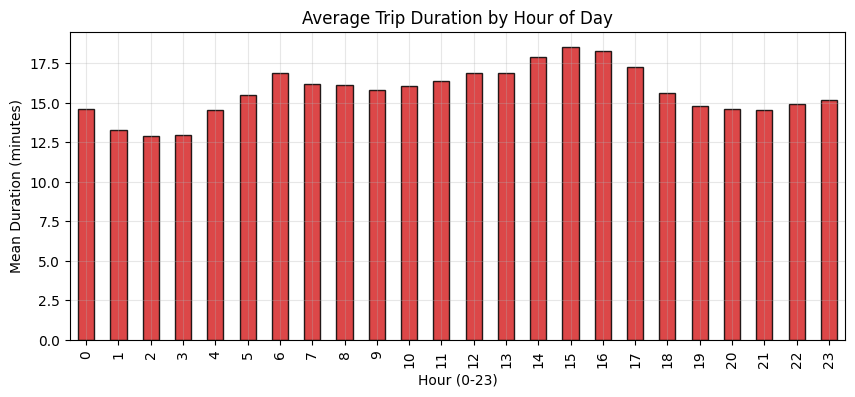

In [ ]:
hourly_avg = train_df.groupby('pickup_hour')['trip_duration_minutes'].mean()
plt.figure(figsize=(10, 4))
hourly_avg.plot(kind='bar', color='#d62728', edgecolor='black', alpha=0.85)
plt.title('Average Trip Duration by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Mean Duration (minutes)')
plt.grid(True, alpha=0.3)
plt.show()
